## Лабораторная 6

1. Необходимо найти датасет на huggingface или kaggle. В датасете обязательно должны быть временные метки.
2. На основе этого датасета необходимо построить рекурсивную или гибридную модель прогнозирования одного из представленных в нем признаков.

**Пример:** 
Набор данных со статистикой по просмотрам видео на YouTube. Можно спрогнозировать будущее количество просмотров видео в зависимости от дня недели, соотношения лайков и дизлайков. Помните, можно опираться на несколько признаков.


In [1]:
import pandas as pd
import numpy as np
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.options.mode.chained_assignment = None 

In [2]:
df = pd.read_csv("playground-series-s5e3/train.csv")

# Смотрим датасет

In [3]:
df.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [4]:
df.describe()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
count,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000
mean,1094.500000,179.948402,1013.602146,26.365799,23.953059,22.170091,20.454566,82.036530,75.721918,3.744429,104.863151,21.804703,0.753425
std,632.342866,105.203592,5.655366,5.654330,5.222410,5.059120,5.288406,7.800654,18.026498,3.626327,80.002416,9.898659,0.431116
min,0.000000,1.000000,999.000000,10.400000,7.400000,4.000000,-0.300000,39.000000,2.000000,0.000000,10.000000,4.400000,0.000000
25%,547.250000,89.000000,1008.600000,21.300000,19.300000,17.700000,16.800000,77.000000,69.000000,0.400000,40.000000,14.125000,1.000000
50%,1094.500000,178.500000,1013.000000,27.800000,25.500000,23.850000,22.150000,82.000000,83.000000,2.400000,70.000000,20.500000,1.000000
75%,1641.750000,270.000000,1017.775000,31.200000,28.400000,26.400000,25.000000,88.000000,88.000000,6.800000,200.000000,27.900000,1.000000
max,2189.000000,365.000000,1034.600000,36.000000,31.500000,29.800000,26.700000,98.000000,100.000000,12.100000,300.000000,59.500000,1.000000


In [5]:
df.isna().sum()

id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    0
windspeed        0
rainfall         0
dtype: int64

In [6]:
corr = df.corr()
corr.style.background_gradient(cmap="coolwarm", axis=1).format(precision=3)

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
id,1.000,0.153,-0.008,0.013,0.014,0.019,0.007,-0.029,0.002,-0.003,-0.004,0.020,0.034
day,0.153,1.000,0.005,0.146,0.154,0.161,0.138,-0.074,-0.048,0.061,0.025,-0.000,-0.000
pressure,-0.008,0.005,1.000,-0.800,-0.817,-0.814,-0.817,-0.120,0.099,-0.257,-0.643,0.266,-0.050
maxtemp,0.013,0.146,-0.800,1.000,0.983,0.966,0.907,-0.073,-0.289,0.452,0.662,-0.354,-0.079
temparature,0.014,0.154,-0.817,0.983,1.000,0.987,0.934,-0.025,-0.249,0.414,0.669,-0.342,-0.050
mintemp,0.019,0.161,-0.814,0.966,0.987,1.000,0.941,0.010,-0.219,0.379,0.664,-0.329,-0.027
dewpoint,0.007,0.138,-0.817,0.907,0.934,0.941,1.000,0.153,-0.088,0.250,0.643,-0.312,0.082
humidity,-0.029,-0.074,-0.120,-0.073,-0.025,0.010,0.153,1.000,0.585,-0.542,-0.012,0.062,0.454
cloud,0.002,-0.048,0.099,-0.289,-0.249,-0.219,-0.088,0.585,1.000,-0.805,-0.127,0.185,0.641
sunshine,-0.003,0.061,-0.257,0.452,0.414,0.379,0.250,-0.542,-0.805,1.000,0.272,-0.242,-0.555


# Предобработка

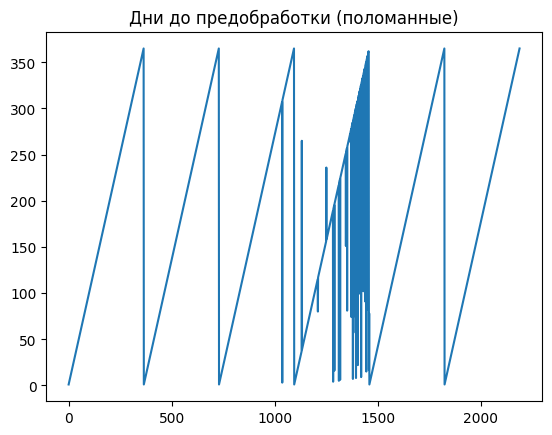

In [7]:
# Метки дней в датасете немного поломанные, мы их чиним в предобработке
plt.plot(df["day"])
plt.title("Дни до предобработки (поломанные)")
plt.show()

In [8]:
class Preprocess:
    def repair_days(self, df: pd.DataFrame):
        # Чиним индексы дней
        length = len(df["day"])
        for j in range(0, length, 365):
            for i in range(j+1, j+365):
                if df["day"][i] - df["day"][i-1] != 1:
                    df["day"][i] = df["day"][i-1] + 1
            for i in range(j+365-2, j-1, -1):
                if df["day"][i+1] - df["day"][i] != 1:
                    df["day"][i] = df["day"][i+1] - 1
        return df

    def process_day(self, df: pd.DataFrame):
        # Делаем проекцию каждого дня на окружность
        df["day_cos"] = np.cos(df["day"] * 2 * np.pi / 365)
        df["day_sin"] = np.sin(df["day"] * 2 * np.pi / 365)
        return df

    def fit(self, df: pd.DataFrame):
        # Эти колонки приводим к интервалу (0, 1)
        self.cols = ['pressure', 'maxtemp', 'temparature', 'mintemp',
        'dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection', 'windspeed']
        self.minmaxscaler = MinMaxScaler(feature_range=(0, 1))
        self.minmaxscaler.fit(df[self.cols])
        return self

    def transform(self, df: pd.DataFrame):
        df = self.repair_days(df)
        df = self.process_day(df)
        df = df.drop(columns=["id", "day"])
        df[self.cols] = self.minmaxscaler.transform(df[self.cols])
        return df

In [9]:
preprocessor = Preprocess()
preprocessor.fit(df)
processed = preprocessor.transform(df)

In [10]:
# Будем предсказывать, будет ли дождь
X_train = processed.drop(columns=["rainfall"])
Y_train = processed["rainfall"]

In [11]:
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.2, random_state=1337, shuffle=False)

In [12]:
# Будем предсказывать на основании предыдущих 90 дней

window = 90

def cut_into_seqs(x):
    return np.array([np.array(x[i:i+window]) for i in range(len(x)-window+1)])

X_train_seq = cut_into_seqs(X_train)
Y_train_seq = cut_into_seqs(Y_train)
X_val_seq = cut_into_seqs(X_val)
Y_val_seq = cut_into_seqs(Y_val)

# Рекуррентная модель

In [13]:
model_gru = keras.Sequential([
    keras.layers.Input(shape=(window, 12)),
    keras.layers.GRU(10, return_sequences=True),
    # keras.layers.GRU(10, return_sequences=True),
    # keras.layers.GRU(10, return_sequences=True),
    keras.layers.Dense(1, activation="sigmoid")
])

In [14]:
model_gru.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),
                loss=keras.losses.BinaryCrossentropy,
                metrics=[keras.metrics.AUC(curve="ROC")])

In [15]:
history = model_gru.fit(X_train_seq, Y_train_seq, validation_data=(X_val_seq, Y_val_seq), epochs=10)

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - auc: 0.6504 - loss: 0.5685 - val_auc: 0.8819 - val_loss: 0.3611
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - auc: 0.8870 - loss: 0.3657 - val_auc: 0.8855 - val_loss: 0.3294
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - auc: 0.8969 - loss: 0.3337 - val_auc: 0.8824 - val_loss: 0.3336
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - auc: 0.9022 - loss: 0.3234 - val_auc: 0.8812 - val_loss: 0.3365
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - auc: 0.9091 - loss: 0.3138 - val_auc: 0.8862 - val_loss: 0.3373
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - auc: 0.9200 - loss: 0.2929 - val_auc: 0.8786 - val_loss: 0.3550
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - auc: 0.9288 - loss: 0.2782 - val_auc: 0.8710 - val_loss: 0.3742
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - auc: 0.9349 - loss: 0.2644 - val_auc: 0.8681 - val_loss: 0.3897
Epoch 9/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - auc: 0.9399

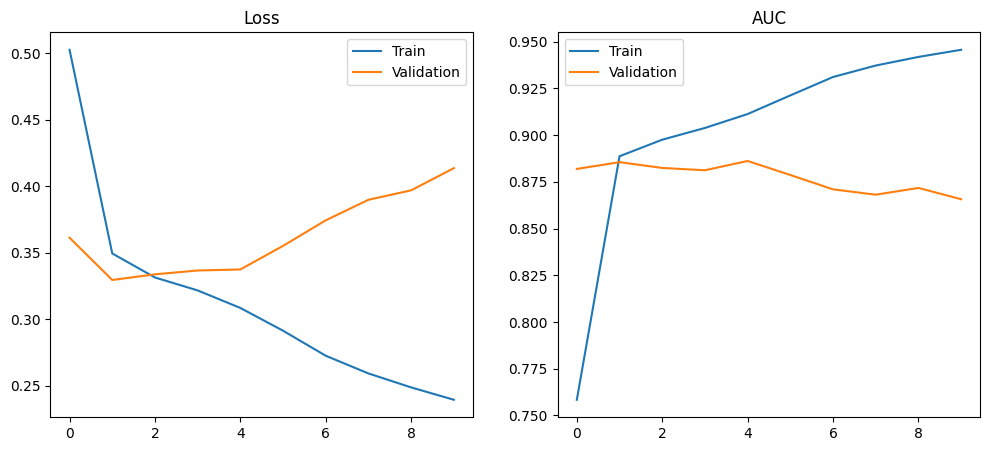

In [17]:
fig = plt.figure(figsize=(12, 5))

fig.add_subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

fig.add_subplot(1, 2, 2)
plt.plot(history.history["auc"], label="Train")
plt.plot(history.history["val_auc"], label="Validation")
plt.title("AUC")
plt.legend()

plt.show()

In [18]:
model_gru.evaluate(X_val_seq, Y_val_seq)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - auc: 0.8856 - loss: 0.3547


[0.4134712219238281, 0.8656877279281616]